In [2]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np

sys.path.append("..")
from utils.psf_correction import PSFCorrection

from models.psf import KingPSF

import matplotlib.pyplot as plt

In [3]:
nside = 128

kp = KingPSF()

psf0 = PSFCorrection(delay_compute=True, num_f_bins=15, nside=nside, f_trunc=0.01)
psf0.psf_r_func = lambda r: kp.psf_fermi_r(r)
psf0.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
psf0.psf_samples = 10000
psf0.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf0.make_or_load_psf_corr(force_recompute=True)

In [4]:
psf1 = PSFCorrection(
    delay_compute=True, num_f_bins='nonuni', nside=nside, f_trunc=0.00,
    n_psf=100000
)
psf1.psf_r_func = lambda r: kp.psf_fermi_r(r)
psf1.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
psf1.psf_samples = 10000
psf1.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf1.make_or_load_psf_corr(force_recompute=True)

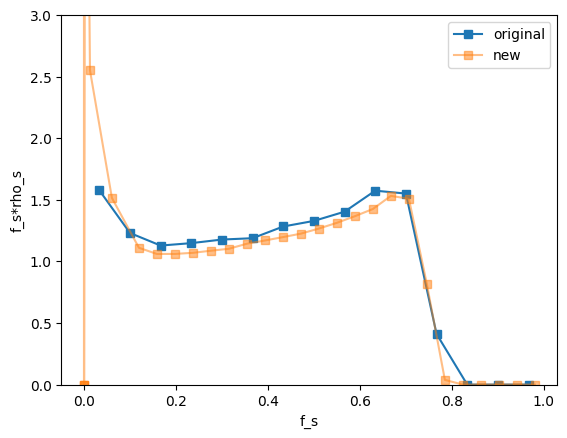

In [5]:
fig, ax = plt.subplots()
ax.plot(psf0.f_ary, psf0.f_ary*psf0.rho_ary, 's-', label='original')
ax.plot(psf1.f_ary, psf1.f_ary*psf1.rho_ary, 's-', alpha=0.5, label='new')
ax.set(xlabel='f_s', ylabel='f_s*rho_s')
ax.set(ylim=(0, 3))
ax.legend();

In [7]:
print(
    np.sum(psf0.df_rho_div_f_ary * psf0.f_ary),
    np.sum(psf0.df_rho_div_f_ary * psf0.f_ary**2)
)
print(
    np.sum(psf1.df_rho_div_f_ary * psf1.f_ary),
    np.sum(psf1.df_rho_div_f_ary * psf1.f_ary**2)
)

6.120760843702323 1.0
2515.3311017073884 1.0


In [14]:
12*128**2

196608